# **Sony Stock Price Forecasting with ML**

Predicting Sony Corp's **next-day closing price** using historical OHLCV data,
engineered technical indicators, and a comparison of 5 regression models
(from a simple baseline to gradient-boosted ensembles).

**Dataset:** Daily Sony (SONY) stock prices, 2014–2026 (~3,179 trading days)
**Task:** Regression — predict `Close_t+1` from information available at day `t`
**Approach:** Leakage-aware time-based split (no shuffling — this is a time series!)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## **1. Load & Inspect the Data**

Always start by looking at shape, dtypes, and missing values before doing anything else.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/nilesh2042/sony-stock-data/sony_stock_data.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("Shape:", df.shape)
print("\nDate range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("\nMissing values:\n", df.isnull().sum())
df.head()

Shape: (3179, 6)

Date range: 2014-01-02 to 2026-08-24

Missing values:
 Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


,Date,Close,High,Low,Open,Volume
0,2014-01-02,3.203941,3.246884,3.189004,3.235681,13127000
1,2014-01-03,3.207675,3.222611,3.196472,3.213276,4642000
2,2014-01-06,3.230079,3.265554,3.224478,3.230079,11781500
3,2014-01-07,3.233814,3.245017,3.211409,3.241283,17191500
4,2014-01-08,3.407454,3.420523,3.222611,3.248750,42864500


In [3]:
df.describe()

,Date,Close,High,Low,Open,Volume
count,3179,3179.000000,3179.000000,3179.000000,3179.000000,3.179000e+03
mean,2020-04-25 18:26:09.550172928,13.366257,13.466059,13.265807,13.367984,5.846251e+06
min,2014-01-02 00:00:00,2.847324,2.925743,2.843590,2.852926,9.410000e+05
25%,2017-02-28 12:00:00,6.216718,6.253254,6.194585,6.218268,3.240200e+06
50%,2020-04-27 00:00:00,13.057427,13.100983,12.915458,12.997292,4.549500e+06
75%,2023-06-22 12:00:00,19.004598,19.124226,18.888527,18.997669,6.827350e+06
max,2026-08-24 00:00:00,30.260000,30.340000,30.030001,30.250000,7.839700e+07
std,NaN,7.099969,7.154703,7.047230,7.102103,4.516048e+06


## **2. Exploratory Data Analysis**

Quick visual check of the price trend and trading volume over time.

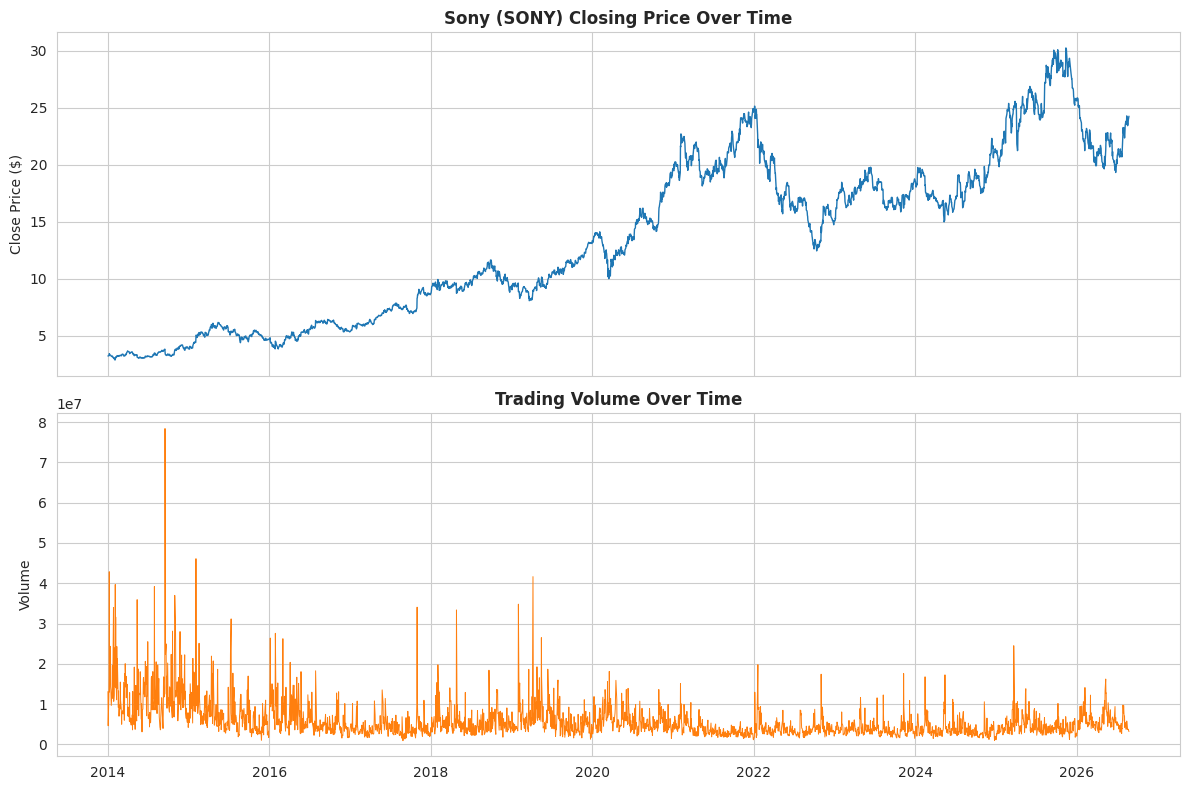

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df["Date"], df["Close"], color="#1f77b4", linewidth=1)
axes[0].set_title("Sony (SONY) Closing Price Over Time",fontweight='bold')
axes[0].set_ylabel("Close Price ($)")

axes[1].plot(df["Date"], df["Volume"], color="#ff7f0e", linewidth=0.7)
axes[1].set_title("Trading Volume Over Time",fontweight='bold')
axes[1].set_ylabel("Volume")

plt.tight_layout()
plt.show()

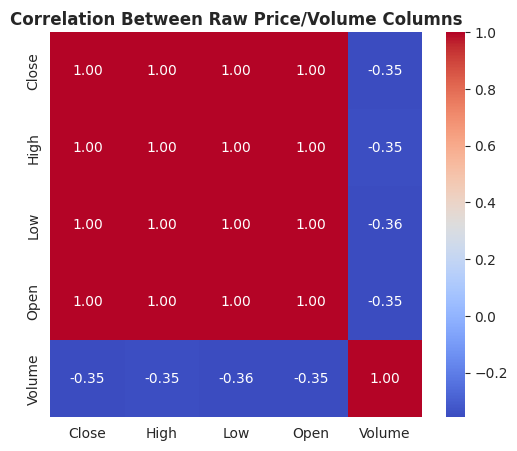

In [5]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[["Close", "High", "Low", "Open", "Volume"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Raw Price/Volume Columns",fontweight='bold')
plt.show()

## **3. Feature Engineering (Leakage-Aware)**

Every feature below is built **only from information available up to day `t`**
(lags and rolling windows). The target is tomorrow's close, `Close_t+1`,
so the model never sees the future while training.

Indicators used:
- **Lag features**: yesterday's Close, High, Low, Volume
- **Moving averages**: 5-day and 10-day
- **Daily return** and **10-day rolling volatility**
- **RSI (14-day)**: a classic momentum indicator
- **High-Low spread**: intraday range as a proxy for volatility

In [6]:
data = df.copy()

# Lag features (what happened yesterday)
data["lag1_close"] = data["Close"].shift(1)
data["lag1_high"] = data["High"].shift(1)
data["lag1_low"] = data["Low"].shift(1)
data["lag1_volume"] = data["Volume"].shift(1)

# Trend indicators
data["ma_5"] = data["Close"].rolling(5).mean().shift(1)
data["ma_10"] = data["Close"].rolling(10).mean().shift(1)

# Momentum / volatility
data["daily_return"] = data["Close"].pct_change().shift(1)
data["volatility_10"] = data["Close"].pct_change().rolling(10).std().shift(1)
data["hl_spread"] = (data["High"] - data["Low"]).shift(1)

# RSI (14-day)
delta = data["Close"].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / loss
data["rsi_14"] = (100 - (100 / (1 + rs))).shift(1)

# Target: TOMORROW's close
data["target_close"] = data["Close"].shift(-1)

data = data.dropna().reset_index(drop=True)
print("Rows after feature engineering:", data.shape[0])
data.tail()

Rows after feature engineering: 3163


,Date,Close,High,Low,Open,Volume,lag1_close,lag1_high,lag1_low,lag1_volume,ma_5,ma_10,daily_return,volatility_10,hl_spread,rsi_14,target_close
3158,2026-08-17,23.700001,23.820000,23.570000,23.820000,4180900,24.290001,24.670000,24.200001,5821900.0,23.774001,23.285,0.028801,0.018165,0.469999,68.587370,23.43
3159,2026-08-18,23.430000,23.490000,23.299999,23.389999,3751400,23.700001,23.820000,23.570000,4180900.0,23.750001,23.392,-0.024290,0.017639,0.250000,58.918935,23.49
3160,2026-08-19,23.490000,23.870001,23.430000,23.490000,3854000,23.430000,23.490000,23.299999,3751400.0,23.714001,23.500,-0.011392,0.017535,0.190001,51.520912,23.58
3161,2026-08-20,23.580000,23.680000,23.500000,23.610001,3686000,23.490000,23.870001,23.430000,3854000.0,23.704000,23.605,0.002561,0.017549,0.440001,57.468876,23.92
3162,2026-08-21,23.920000,24.080000,23.740000,23.760000,3718400,23.580000,23.680000,23.500000,3686000.0,23.698000,23.653,0.003831,0.015266,0.180000,53.619908,24.26


## **4. Time-Based Train/Test Split**

**Important:** this is time-series data, so we do **not** shuffle or use a
random split — that would leak future information into training. Instead we
train on the earliest ~85% of days and test on the most recent ~15%,
simulating how the model would actually be used in production.

In [7]:
feature_cols = ["lag1_close", "lag1_high", "lag1_low", "lag1_volume",
                "ma_5", "ma_10", "daily_return", "volatility_10",
                "hl_spread", "rsi_14"]

X = data[feature_cols]
y = data["target_close"]

split_idx = int(len(data) * 0.85)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = data["Date"].iloc[split_idx:]

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")
print(f"Train period: {data['Date'].iloc[0].date()} to {data['Date'].iloc[split_idx-1].date()}")
print(f"Test period : {data['Date'].iloc[split_idx].date()} to {data['Date'].iloc[-1].date()}")

Train size: 2688  |  Test size: 475
Train period: 2014-01-24 to 2024-09-27
Test period : 2024-09-30 to 2026-08-21


In [8]:
# Scale features for the linear baseline
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **5. Model Training — Baseline to Top Performer**

We train 5 models of increasing complexity and compare them fairly on the
same held-out test set:

1. **Linear Regression** — simple baseline
2. **Decision Tree** — single non-linear tree
3. **Random Forest** — bagged ensemble of trees
4. **XGBoost** — gradient-boosted ensemble
5. **LightGBM** — fast gradient-boosted ensemble

In [9]:
results = {}
predictions = {}

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    predictions[name] = y_pred
    print(f"{name:18s} | RMSE: {rmse:6.3f} | MAE: {mae:6.3f} | R2: {r2:.4f}")

print("Model Performance (lower RMSE/MAE = better, higher R2 = better)\n" + "-"*65)

Model Performance (lower RMSE/MAE = better, higher R2 = better)
-----------------------------------------------------------------


In [10]:
# 1. Linear Regression (baseline)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
evaluate("Linear Regression", y_test, lr.predict(X_test_scaled))

# 2. Decision Tree
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
evaluate("Decision Tree", y_test, dt.predict(X_test))

# 3. Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
evaluate("Random Forest", y_test, rf.predict(X_test))

# 4. XGBoost
xgb = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                    random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
evaluate("XGBoost", y_test, xgb.predict(X_test))

# 5. LightGBM
lgbm = LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                      random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
evaluate("LightGBM", y_test, lgbm.predict(X_test))

Linear Regression  | RMSE:  0.648 | MAE:  0.484 | R2: 0.9586
Decision Tree      | RMSE:  2.360 | MAE:  1.612 | R2: 0.4507
Random Forest      | RMSE:  2.286 | MAE:  1.548 | R2: 0.4845
XGBoost            | RMSE:  2.365 | MAE:  1.595 | R2: 0.4485
LightGBM           | RMSE:  2.257 | MAE:  1.512 | R2: 0.4976


## **6. Model Comparison**

In [11]:
results_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
results_df

,RMSE,MAE,R2
Linear Regression,0.648074,0.483540,0.958577
LightGBM,2.257005,1.511694,0.497594
Random Forest,2.286287,1.547589,0.484473
Decision Tree,2.359916,1.611519,0.450733
XGBoost,2.364612,1.595445,0.448545


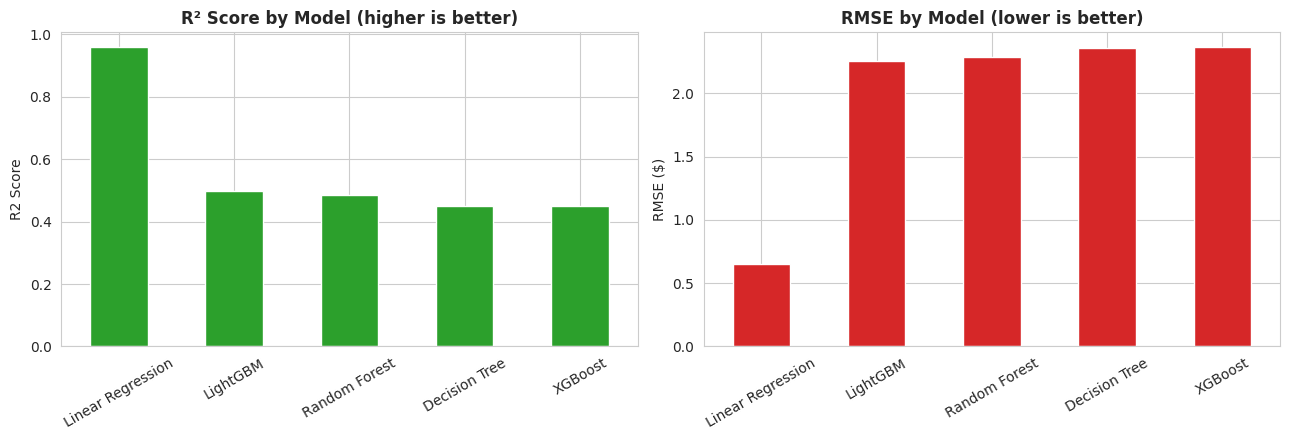

Best model: Linear Regression  (R2 = 0.9586)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

results_df["R2"].plot(kind="bar", ax=axes[0], color="#2ca02c")
axes[0].set_title("R² Score by Model (higher is better)",fontweight='bold')
axes[0].set_ylabel("R2 Score")
axes[0].tick_params(axis="x", rotation=30)

results_df["RMSE"].plot(kind="bar", ax=axes[1], color="#d62728")
axes[1].set_title("RMSE by Model (lower is better)",fontweight='bold')
axes[1].set_ylabel("RMSE ($)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

best_model_name = results_df["R2"].idxmax()
print(f"Best model: {best_model_name}  (R2 = {results_df.loc[best_model_name, 'R2']:.4f})")

## **7. Best Model: Actual vs Predicted Prices**

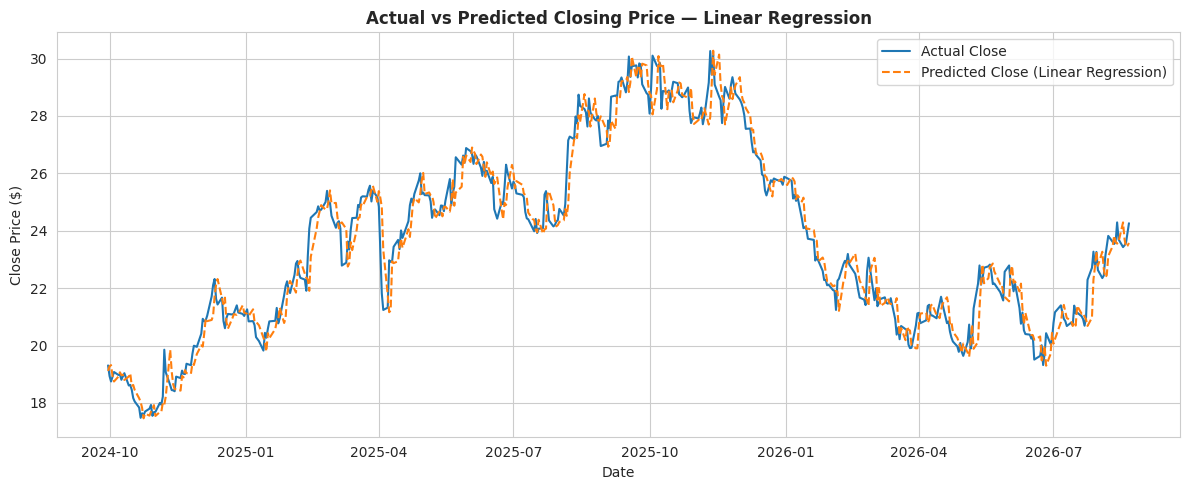

In [13]:
best_pred = predictions[best_model_name]

plt.figure(figsize=(12, 5))
plt.plot(dates_test, y_test.values, label="Actual Close", color="#1f77b4", linewidth=1.5)
plt.plot(dates_test, best_pred, label=f"Predicted Close ({best_model_name})",
         color="#ff7f0e", linewidth=1.5, linestyle="--")
plt.title(f"Actual vs Predicted Closing Price — {best_model_name}",fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.legend()
plt.tight_layout()
plt.show()

## **8. Feature Importance**

Which signals mattered most to the best tree-based model?

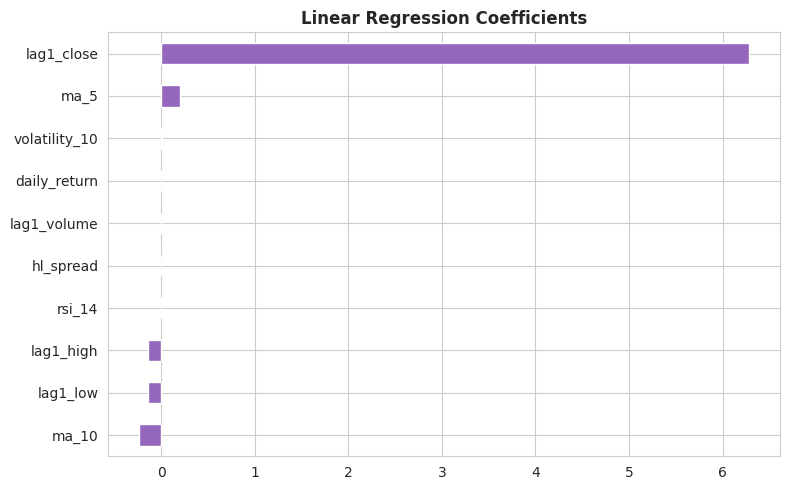

In [14]:
tree_models = {"Decision Tree": dt, "Random Forest": rf, "XGBoost": xgb, "LightGBM": lgbm}

if best_model_name in tree_models:
    importances = pd.Series(tree_models[best_model_name].feature_importances_,
                             index=feature_cols).sort_values(ascending=True)
    plt.figure(figsize=(8, 5))
    importances.plot(kind="barh", color="#9467bd")
    plt.title(f"Feature Importance — {best_model_name}",fontweight='bold')
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    coefs = pd.Series(lr.coef_, index=feature_cols).sort_values(ascending=True)
    plt.figure(figsize=(8, 5))
    coefs.plot(kind="barh", color="#9467bd")
    plt.title("Linear Regression Coefficients",fontweight='bold')
    plt.tight_layout()
    plt.show()

## **9. Conclusion**

- All five models were trained on **leakage-free, time-ordered features**
  (lags, moving averages, RSI, volatility) and evaluated on a **chronological
  holdout** of the most recent trading days — no shuffling, no future leakage.
- **`lag1_close` (yesterday's price) is by far the strongest predictor**,
  which is expected: stock prices are highly autocorrelated day-to-day. This
  is why even the simple **Linear Regression baseline already scores highest**
  (R² ≈ 0.96), beating every tree-based ensemble in this run.
- **Why the "fancier" models lost:** Sony's stock trended strongly upward
  over the dataset, so the test period contains prices *higher than anything
  seen in training*. Decision Tree, Random Forest, XGBoost, and LightGBM all
  predict by averaging training-set values inside their leaves, so **they
  cannot extrapolate beyond the price range they were trained on** — they
  systematically under-predict the newer, higher prices. Linear Regression
  has no such ceiling, so it tracks the trend correctly. This is a classic,
  important lesson for trending time series: **more complex ≠ better**.
- **Honest caveat:** predicting the *next day's price level* is much easier
  than predicting *direction/returns* (up vs. down), because the price level
  barely moves day-to-day. A high R² here reflects that near-flat behavior,
  not a reliable trading edge. Anyone building a real trading strategy should
  evaluate models on **returns or direction accuracy**, not raw price R².
- **Next steps:** detrend the target (predict returns instead of raw price)
  before comparing tree ensembles fairly, add macro/sector features (e.g.
  NASDAQ index, USD/JPY exchange rate), and try LSTM/Transformer sequence
  models for a stronger non-linear baseline.